{'Linear Regression': LinearRegression(), 'Ridge': Ridge(), 'Lasso': Lasso(), 'Random Forest Regressor': RandomForestRegressor(random_state=42)}
Model Performance Comparison :
                               MAE        RMSE        R2
Random Forest Regressor  30.258575   80.806491  0.895722
Lasso                    53.757877  148.681486  0.646968
Ridge                    53.759068  148.683275  0.646960
Linear Regression        53.759068  148.683275  0.646960

Best Model :  Random Forest Regressor


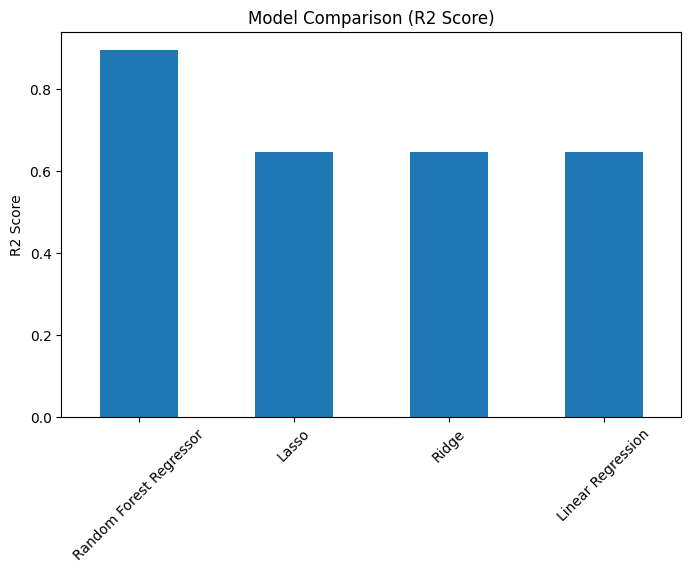

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys 
sys.path.append("/home/ishanya-poddar/Desktop/Projects/ML + NLP/ML&NLP/src")

from data_models import regression_models
from data_evaluation import regression_metrics 
from sklearn.model_selection import train_test_split

df = pd.read_csv("/home/ishanya-poddar/Desktop/Projects/ML + NLP/ML&NLP/Datasets/Processed Datasets/cleaned_data.csv")

# We will perform simple feature selection 
features = ["price", "freight_value"]
X = df[features]
y = df["order_total_price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

models = regression_models()

results = {}

# We will train models 
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = regression_metrics(y_test, preds)

# We will convert results to DataFrame 
results_df = pd.DataFrame(results).T 

# We will sort by R2 score 
results_df = results_df.sort_values(by = "R2", ascending = False)

print("Model Performance Comparison :")
print(results_df)

# We will identify best model 
best_model_name = results_df.index[0]
print("\nBest Model : ", best_model_name)

# We will plot comparison 
results_df["R2"].plot(kind = "bar", figsize = (8, 5))
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.xticks(rotation = 45)
plt.show()

# We will save results in csv file 
results_df.to_csv("/home/ishanya-poddar/Desktop/Projects/ML + NLP/ML&NLP/Datasets/Processed Datasets/regression_model_results.csv")